In [36]:
!pip install numba==0.60.0

  Using cached numba-0.60.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.7 kB)
  Using cached llvmlite-0.43.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.8 kB)
Using cached numba-0.60.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.7 MB)
Using cached llvmlite-0.43.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (43.9 MB)
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.44.0
    Uninstalling llvmlite-0.44.0:
      Successfully uninstalled llvmlite-0.44.0
  Attempting uninstall: numba━━━━━━━━━━━━━━━━━━━ 0/2 [llvmlite]
    Found existing installation: numba 0.61.2 0/2 [llvmlite]
    Uninstalling numba-0.61.2:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [numba]
      Successfully uninstalled numba-0.61.2━━━━━━━━━━━━━━━━━━━ 1/2 [numba]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]32m1/2 [numba]


In [40]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
from funcs import get_delta, compute_Pk, compute_Bk,calculate_acc_from_phi_k, correct_pos, compute_XPk, get_roots,MAS_correction, terms_root, get_roots_gamma, terms_root_gamma, get_roots_overdensity
import scipy
import h5py, itertools
from scipy.fft import *

import progressbar
import inspect
import os
from sys import getsizeof

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib.colors as colors
import colorsys
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Circle, Rectangle
from matplotlib.patheffects import withStroke
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter
import matplotlib.ticker as mtick

# Pylians
import readgadget
import MAS_library as MASL
import Pk_library as PKL
import plotting_library as PL
import smoothing_library as SL

# Emulators
import symbolic_pofk.syrenhalofit as syrenhalofit
import symbolic_pofk.linear as linear
import astropy.cosmology as cosmo

# Conveniences
format_float = lambda z: "%ip%i"%(int(z // 1), int(z%1 *10))

def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    # remove leading "+" and strip leading zeros
    b = int(b)
    return a + r"$\times 10^{%i}$"%b

plt.style.use("dark_background")

import time
np.__version__

'1.23.5'

In [41]:
# For opti tests
import pyfftw
import numba
from numba import njit, jit

In [42]:
import psutil
from psutil._common import bytes2human
print("total memory:" ,bytes2human(psutil.virtual_memory()[0]))
print('memory % used:', psutil.virtual_memory()[2])
print("number of cpus :", os.cpu_count())

total memory: 251.5G
memory % used: 21.8
number of cpus : 128


# 0) Very brief summary
**A handful of equation for different test cases**

The goal is to perturbed particles positions 

\begin{align}
\mathbf{x}_i' = \mathbf{x}_i + \nabla\phi(\mathbf{x}_i)
\end{align}

We use the convention that $\Delta$ designates the fractional overdensity field, meaning in comoving space

$\Delta(\mathbf{x}) = \frac{\rho(\mathbf{x}) - \rho_\text{mean}}{\rho_\text{mean}}$
with $\rho(\mathbf{x}) = \sum_{i=1}^n \delta(\mathbf{x} - \mathbf{x}_i)$ defined with the Delta function.

The main equation for the Fourier transform of the density field of the perturbed tracer $\Delta_k^{'}$ is

\begin{align}
|\Delta^{'}_\mathbf{k}|^2 &= \Delta^{'}_\mathbf{k}\Delta^{' \ast}_\mathbf{k}  \\
&= \left[ \Delta_\mathbf{k} + k^2\phi_{\mathbf{k}} +
\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}} 
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}  
\right) \right] \times \nonumber\\
&\left[\Delta^{\ast}_\mathbf{k} + k^2\phi_{\mathbf{k}}^{\ast} +
\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber\\
|\Delta^{'}_\mathbf{k}|^2 &\approx_{\mathcal{O}(\phi^2)} |\Delta_{\mathbf{k}}|^2 + k^4 |\phi_{\mathbf{k}}|^2 + \frac{1}{V^2} \sum_{\mathbf{q},\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \phi_{\mathbf{q}}
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast} \nonumber\\
 &+ 2 \operatorname{Re}\left[ k^2\Delta_{\mathbf{k}}\phi_{\mathbf{k}}^{\ast} +\frac{k^2}{V} \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{k}}\phi_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast} \right. \nonumber \\
 &+\left. \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber 
\end{align}

# 1) Setup and load data
The Quijote fiducial simulations parameters are reminded in the [documentation](https://quijote-simulations.readthedocs.io/en/latest/types.html). 
We will try to perturb a L-PICOLA snapshot, with the reference being either the Quijote simulation at the same seed or from the [symbolik_pofk](https://github.com/DeaglanBartlett/symbolic_pofk) emulator.

In [43]:
params=["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
cosmology = {"sigma_8":0.834, "n_s":0.9624, "h":0.671, "Omega_b":0.049,
            "Omega_m":0.3175}

In [44]:
redshift = 0.5
a = 1 / (1+redshift)
z_str = format_float(redshift)
seed = 1

nbody = "/anvil/scratch/x-nchartier/snapshots/quijote_fid_z%s_seed%i/snapdir_003/snap_003"%(z_str,seed)
nbodystr = "Quijote"

app = "/anvil/scratch/x-nchartier/snapshots/cola_fid_z%s_seed%i/Cola1_20steps_mesh512_nLPTpos0p5_z0p500"%(z_str,seed)
appstr = "L-PICOLA"
ptype   = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

# TODO: test on fastpm sims with saved DM particles
# fpm = "/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm/L1000-N128/%i/"%seed
# file = h5py.File(os.path.join(fpm, "nbody.h5"))
# print(file.keys())
# data = file['0.666667']
# print(data.keys())
# file.close()

In [45]:
# read header for nbody
header   = readgadget.header(nbody)
BoxSize  = header.boxsize/1e3  #Mpc/h
print("BoxSize = %.1f Mpc"%BoxSize)
Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3)
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
print(r"$\Omega_m = %.4f$"%Omega_m)
Omega_l  = header.omega_l      #value of Omega_l
print(r"$\Omega_{\Lambda} = %.4f$"%Omega_l)
h        = header.hubble       #value of h
print(r"$h=%.4f$"%h)
#redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble)
Hubble_0   = 100.0*np.sqrt(Omega_m+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble_0)
print(h*Hubble_0)

# read positions, velocities and IDs of the particles
pos_nb = readgadget.read_block(nbody, "POS ", ptype)/1e3 #positions in Mpc/h
#vel_nb = readgadget.read_block(nbody, "VEL ", ptype)     #peculiar velocities in km/s
#ids_nb = readgadget.read_block(nbody, "ID  ", ptype)-1   #IDs starting from 0

BoxSize = 1000.0 Mpc
[1.]
$\Omega_m = 0.3175$
$\Omega_{\Lambda} = 0.6825$
$h=0.6711$
132.44102461095656
100.0
67.11


In [46]:
# read header for nbody
header   = readgadget.header(app)

Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3) # sanity check

# read positions, velocities and IDs of the particles
pos_pm = readgadget.read_block(app, "POS ", ptype)/1e3 #positions in Mpc/h
#vel_pm = readgadget.read_block(app, "VEL ", ptype)     #peculiar velocities in km/s
#ids_pm = readgadget.read_block(app, "ID  ", ptype)-1   #IDs starting from 0

[1.]


Compute overdensity fields and Power spectra from snapshots

In [47]:
grid = 256
BoxSize=1000.0 # Mpc/h
voxel_size = np.array(3*[BoxSize/grid])
MAS='CIC'
MAS_index=2

# PM
delta_pm = get_delta(pos=pos_pm, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_pm, Pk_pm, _, _ = compute_Pk(delta_pm, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# N-body (=target if no emulator)
delta_nb = get_delta(pos=pos_nb, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_nb, Pk_nb, _, _ = compute_Pk(delta_nb, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# Cross-Spectrum
k_X, Pk_X, _, _ = compute_XPk(delta_pm, delta_nb, BoxSize=BoxSize, MAS=[MAS, MAS] , axis=0)
rk = Pk_X/np.sqrt(Pk_pm*Pk_nb)


Using CIC mass assignment scheme
Time taken = 1.814 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.81 seconds

Using CIC mass assignment scheme
Time taken = 1.860 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Computing power spectra of the fields...
Time FFTS = 0.57
Time loop = 0.36
Time taken = 0.93 seconds


In [48]:
def plot_dFields(snapList, x_min, x_max, y_min, y_max, z_min, z_max, grid, ptypes, plane, MAS, scale, 
                 colmap, dmin, dmax, redshift, titleList):  
    """
    Plot projected density (or overdensity) field for each snapshot in snapList 
    """ 
    W_k = SL.FT_filter_2D(x_max - x_min, 0, grid, "Top-Hat", 5)
    P = len(snapList)
    save_density_field = False
    
    #Initialize axes depending on the number of snapshots to analyze
    if P%2 == 0 and P > 2:
      fig, axes = plt.subplots(int(P/2), int(P/2), sharex = False, sharey = False, squeeze = False, figsize = (12,12))
    else:
      fig, axes = plt.subplots(1, P, sharex = False, sharey = False, squeeze = False, figsize = (14, 9))
      axes.shape


    #To have the same colorbar scales for all plots, we need to compute all the overdensities
    OD_list = []
    
    for k in np.arange(0,P):
       #overdensity = PL.density_field_2D(snapList[k], x_min, x_max, y_min, y_max, z_min, z_max, grid, ptypes, plane, MAS, save_density_field) # For Pylians2
       dx, x, dy, y, overdensity = PL.density_field_2D(snapList[k], x_min, x_max, y_min, y_max, z_min, z_max, 
                                                       grid, ptypes, plane, MAS, save_density_field) # For Pylians3
       
       #overdensity[np.where(overdensity == 0)] = np.sort(np.unique(overdensity))[1] #prevents errors with log norm
       overdensity[np.where(overdensity < dmin)] = dmin
       overdensity[np.where(overdensity > dmax)] = dmax
       overdensity = SL.field_smoothing_2D(overdensity, W_k, 4)
       OD_list.append(overdensity)

    min_OD = min(overdensity.min() for overdensity in OD_list)
    max_OD = max(overdensity.max() for overdensity in OD_list)
    
    
    #For each snapshot  
    for k in np.arange(0, P):
        
        len_x, off_x, len_y, off_y, depth, BoxSize_slice = PL.geometry(snapList[k], plane, x_min, x_max, y_min, 
                                                                       y_max, z_min, z_max)
        #Compute overdensity field with Pylians plotting library
        
        ax = axes.flat[k] #flat not to bother with the 2D case
        
        ax.set_xlim([off_x, off_y+len_x])  #set the range for the x-axis
        ax.set_ylim([off_y, off_y+len_y])  #set the range for the y-axis
        ax.set_xlabel(r'$h^{-1}{\rm Mpc}$',fontsize= 24, labelpad = 5)  #x-axis label
        #ax.set_ylabel(r'$h^{-1}{\rm Mpc}$',fontsize= 24, labelpad = -5)  #y-axis label
        #ax.set_title(os.path.split(snapList[k])[1], fontsize = 14)        
        ax.set_title(titleList[k], fontsize = 22)
        ax.tick_params(axis='x', which='major', pad=2, labelsize = 22)
        ax.tick_params(axis='y', which='major', pad=2, labelsize = 22)
        
        if scale == "linear":
            ca = ax.imshow(OD_list[k], cmap = plt.get_cmap(colmap),origin='lower',
                     extent=[off_x, off_x+len_x, off_y, off_y+len_y],
                     interpolation='sinc',
                     vmin=min_OD,vmax=max_OD)
            
        else:   
            ca = ax.imshow(OD_list[k], cmap = plt.get_cmap(colmap),origin='lower',
                     extent=[off_x, off_x+len_x, off_y, off_y+len_y],
                     interpolation='sinc',
                     norm = LogNorm(vmin=min_OD, vmax=max_OD))
        
        #next lines adjust the colorbar dimensions next to the subplot
        divider = make_axes_locatable(ax)
        cad = divider.append_axes("right", size="8%", pad=0.05)
        plt.subplots_adjust(bottom = 0.1, top = 0.9, left = 0.09, right = 0.94, wspace = 0.35)
        cbar = plt.colorbar(ca, cax=cad)
        cbar.ax.tick_params(axis = "both", labelsize = 22)      


Computing density field...
Expected mass = 1.1220728e+18
Computed mass = 1.1220731e+18
mass density = 8.81221e+10
0.087317914 < rho/<rho> < 23.772453

Computing density field...
Expected mass = 1.1222171e+18
Computed mass = 1.1222175e+18
mass density = 8.81221e+10
0.13087106 < rho/<rho> < 18.21459


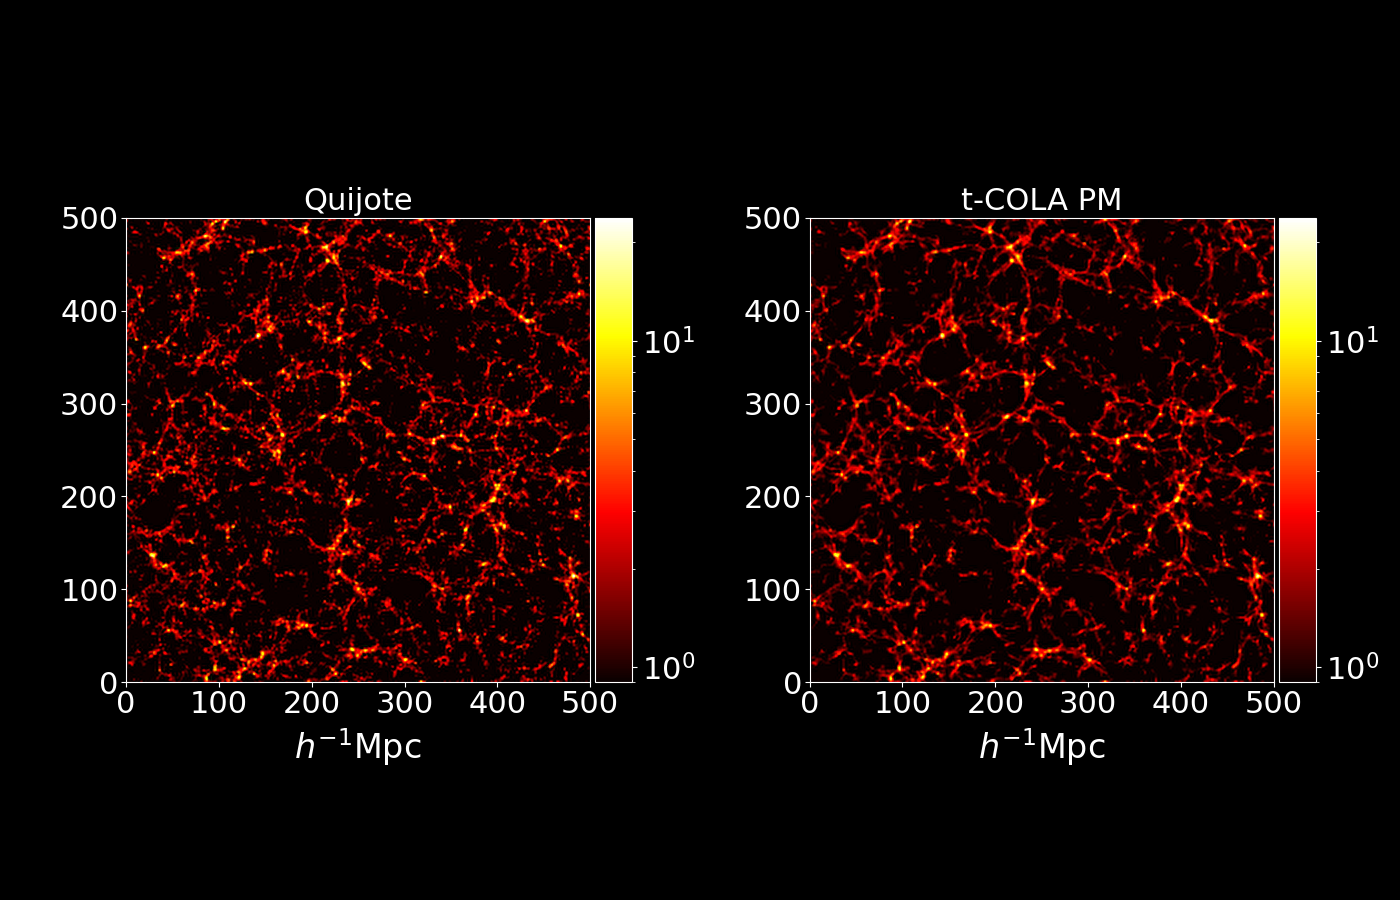

In [49]:
snapList = [nbody, app]
# For plotting
kNyquist = 0.5 * grid/BoxSize
indicateNyquist = False
dmin = 0.9
dmax = 80
#%% 2D PROJECTED OVERDENSITY FIELD 

x_min = 0.0;  x_max = 500.0
y_min = 0.0;  y_max = 500.0
z_min = 40.0;  z_max = 90.0

plane = 'XY'
scale = 'log' #'linear' or 'log'
colmap = 'hot'
#colmap = "YlGnBu"
#colmap = "BuPu"
save_density_field = False
axList = ["Quijote", "t-COLA PM"]

plot_dFields(snapList, x_min, x_max, y_min, y_max, z_min, z_max, grid, ptype, plane, MAS, scale, colmap,
                dmin, dmax, redshift, axList)

In [50]:
# Emulate P(k)
pk_halofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial',
                extrapolate=True, which_params='Bartlett', add_correction=False)

pk_syrenhalofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                    Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial', 
                    extrapolate=True, which_params='Bartlett', add_correction=True)



/home/x-nchartier/miniconda3/envs/pkcorr/lib/python3.10/site-packages/symbolic_pofk/linear.py:244: UserWarning: Using Bartlett et al. formula outside tested regime. Due to problems with the Colossus Eisenstein & Hu fit on                 large scales (typically a 2 percent offset), it is strongly recommended to use extrapolate=False.
  warnings.warn(


In [51]:
# Pylians uses the diagonal of the cube for kmax, not k Nyquist !
print(k_pm.max())
print(k_pm.shape)
print(np.pi *grid/BoxSize)
print(np.pi *grid/BoxSize * np.sqrt(3))

1.3902843163141774
(221,)
0.8042477193189871
1.3929979117318794


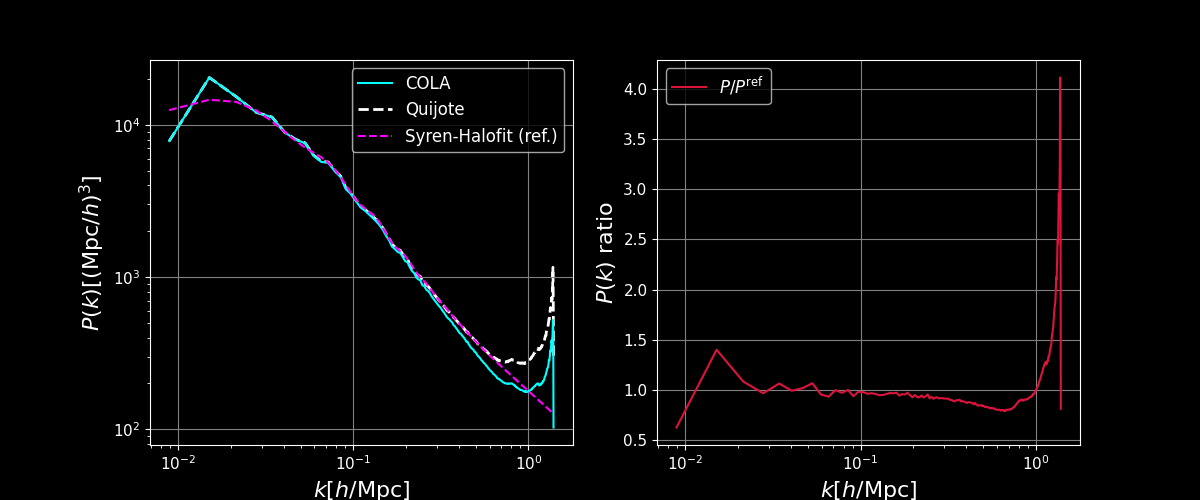

In [52]:
#plt.style.use("default")
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]; ax2 = axes[1]
ax1.plot(k_pm, Pk_pm, label="COLA", zorder = 3, color = "cyan")
ax1.plot(k_nb, Pk_nb,"--", label='Quijote', zorder = 1, lw = 2, color = "white")
ax1.plot(k_pm, pk_syrenhalofit, label='Syren-Halofit (ref.)', color = "magenta", ls = "--", zorder = 5)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax1.tick_params(labelsize = 11)

ax2.plot(k_pm, Pk_pm/pk_syrenhalofit, label='$P/P^{\mathrm{ref}}$', zorder = 3, color = "crimson")
ax2.legend(fontsize = 12)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax2.set_yscale("linear")
ax2.set_xscale("log")
ax2.set_ylabel(r"$P(k)$" + " ratio", fontsize = 16)
ax2.grid(color = "grey")
ax2.tick_params(labelsize = 11)

/tmp/ipykernel_4136982/633734599.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1,1, figsize = (6,4))


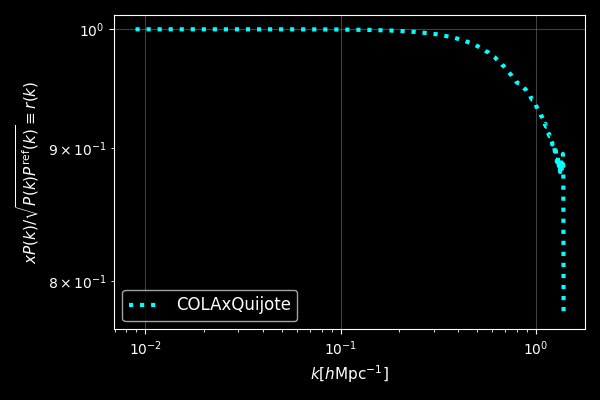

In [53]:
fig, axes = plt.subplots(1,1, figsize = (6,4))
axes.plot(k_X, rk, ':', label='COLAxQuijote', zorder= 10, lw = 3, color = "cyan")
axes.set_xscale("log")
axes.set_yscale("log")
axes.legend(fontsize = 12)
axes.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
axes.set_ylabel(r"$xP(k)/\sqrt{P(k)P^{\mathrm{ref}}(k)} \equiv r(k)$", fontsize = 11, rotation = 90)
axes.grid(color = "gray", alpha = 0.5)
plt.tight_layout()

# 2) Dark matter perturbation tests

## 2-1) Perfect correlation case
$\Phi(k) = \frac{\gamma_k}{k^2} \Delta_k$

If we take the expectation with respect to Delta, power spectrum, as well as bispectum and trispectrum terms appear

\begin{align}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} &\approx (2\pi)^3P(k) + \gamma_k^2(2\pi)^3P(k) +\frac{1}{V^2} \sum_{\mathbf{q},\mathbf{q'}} \frac{\gamma_{q'}\gamma_{q}}{q^2 q'^{2}}(\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}
 \Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast}] \nonumber \\
&+ 2 \operatorname{Re}\left[ (2\pi)^3 \gamma_k P(k) +\frac{1}{V} \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \gamma_k \frac{\gamma_q}{q^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}] \right. \nonumber \\
 &+\left. \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2}
\mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}]
    +\frac{1}{2V} \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot (\mathbf{k} -\mathbf{q}))\frac{\gamma_q}{q^2} \frac{\gamma_{|k-q|}}{|k-q|^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{k-q}}^{\ast}]
 \right. \nonumber \\
 &+ \left. \frac{1}{2V^2} \sum_{\mathbf{q}, \mathbf{q'}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot \mathbf{q'})\frac{\gamma_q}{q^2} \frac{\gamma_q'}{q'^2}\mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast}] \right]
\end{align}

**Question**

Can we afford dropping bispectrum and trispectrum terms and simply solving for the polynomial below ? 
\begin{equation}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} = P(k) + \gamma_k^2 P(k) + 2 \gamma_k P(k) 
\end{equation}

(127, 3)
(127,)


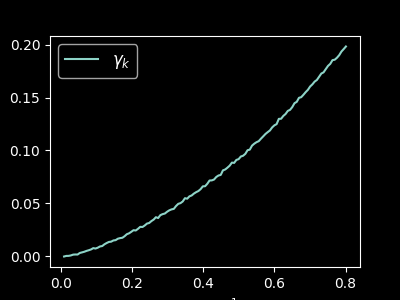

In [54]:
kN = np.pi *grid/BoxSize
inds = np.where(k_nb <= kN)
k = k_nb[inds]

# With beta convention
roots_alt, coeffs_alt=get_roots(k, Pk_pm[inds], Pk_nb[inds])

# With beta convention and for overdensity case
#rootso, coeffso=get_roots_overdensity(k, Pk_pm[inds],  Pk_nb[inds], rk, BoxSize=1000.)

# With gamma convention
roots, coeffs=get_roots_gamma(k, Pk_pm[inds], Pk_nb[inds])
#print(roots)
print(coeffs.shape)

fig, ax = plt.subplots(figsize = (4,3), ncols = 1, nrows= 1)
#plt.plot(roots[:,1].real, label=r'$\beta$')
ax.plot(k, roots[:,1].real, label=r'$\gamma_k$')
# plt.loglog()
ax.legend(fontsize = 12)
ax.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
# Note: this function still uses the notes with beta_k = gamma_k /k^2
at, bt, ct = terms_root(k, Pk_pm[inds], Pk_nb[inds])
print(k.shape)

Text(0.5, 0.98, 'Perfect correlation case, terms contribution')

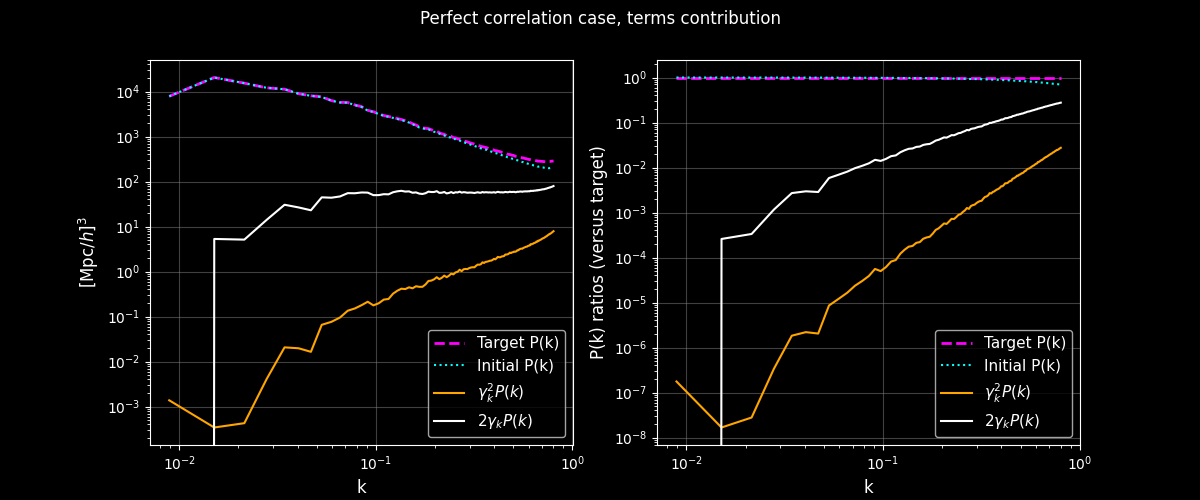

In [55]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

ax1.plot(k, Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k, Pk_pm[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(k, coeffs[:,0]*(roots[:,1].real)**2, color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax1.plot(k, coeffs[:,1]*roots[:,1].real, color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax1.set_xlabel("k", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(k, Pk_nb[inds]/Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_nb[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax2.plot(k, coeffs[:,0]*(roots[:,1].real)**2/Pk_nb[inds], color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax2.plot(k, coeffs[:,1]*roots[:,1].real/Pk_nb[inds], color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax2.set_xlabel("k", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution")

### FFT tests and plots
I take the occasion to compare the computation times for two different ways of using pyfftw.

In [89]:
# Perform the FFT for delta(k)
start = time.time()
#N_CPU = 16
prec_dict = {"float32":"complex64", "float64": "complex128"}
prec_in ="float32"
prec_out = prec_dict[prec_in]

NCPU_list = [1,2,4,8,16,32]
ct1_list = []
ct2_list = []
ct3_list = []

for N_CPU in NCPU_list:

    # Initialize
    arr_in  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
    # Fill data in advance with builders interface
    arr_in[:] =  delta_pm.astype(prec_in)
    # Instantiate FFTW object
    fftw_object = pyfftw.builders.rfftn(arr_in,  axes=(0,1,2), threads=N_CPU)
    # Compute transform
    delta_pm_fourier_alt = fftw_object()
    end = time.time()
    print("First computation: %.3f seconds"%(end-start))
    ct1_list.append(end-start)
    
    # ALTERNATIVE COMPUTATION
    start = time.time()
    a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
    a_out = pyfftw.empty_aligned((grid,grid,grid//2+1),dtype='complex64')
    # plan FFTW
    fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                            flags=('FFTW_ESTIMATE',),
                            direction='FFTW_FORWARD', threads=N_CPU)
    # put input array into delta_r and perform FFTW
    a_in[:] = delta_pm.astype(prec_in)
    delta_pm_fourier = fftw_plan(a_in,a_out)
    end = time.time()
    ct2_list.append(end-start)
    print("Second computation: %.3f seconds"%(end-start))

    # With numpy interface
    start = time.time()
    delta_pm_fourier_np = pyfftw.interfaces.numpy_fft.rfftn(delta_pm.astype(prec_in))
    end = time.time()
    ct3_list.append(end-start)
    print("Numpy interface: %.3f seconds"%(end-start))

    print("Norm of difference fftw 2 methods: %.3f"%(np.linalg.norm(delta_pm_fourier-delta_pm_fourier_alt)))
    print("Norm of difference fftw np: %.3f"%(np.linalg.norm(delta_pm_fourier-delta_pm_fourier_np)), "\n")

    if N_CPU != NCPU_list[-1]:
        del delta_pm_fourier, delta_pm_fourier_alt, arr_in, a_in, fftw_object, fftw_plan


print("Norm of difference fftw 2 methods: %.3f"%(np.linalg.norm(delta_pm_fourier-delta_pm_fourier_alt)))
print("Norm of difference fftw np: %.3f"%(np.linalg.norm(np.fft.fftshift(delta_pm_fourier)-np.fft.fftshift(delta_pm_fourier_np))), "\n")    
del delta_pm_fourier_alt

First computation: 0.308 seconds
Second computation: 0.285 seconds
Numpy interface: 0.317 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.558 seconds
Second computation: 0.172 seconds
Numpy interface: 0.308 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.505 seconds
Second computation: 0.127 seconds
Numpy interface: 0.307 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.506 seconds
Second computation: 0.104 seconds
Numpy interface: 0.307 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.486 seconds
Second computation: 0.079 seconds
Numpy interface: 0.306 seconds
Norm of difference fftw 2 methods: 0.000
Norm of difference fftw np: 0.000 

First computation: 0.459 seconds
Second computation: 0.080 seconds
Numpy interface: 0.307 seconds
Norm of difference fftw 2 m

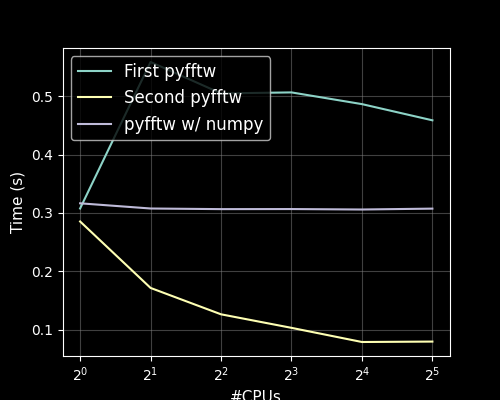

In [90]:
fig, ax = plt.subplots(figsize = (5,4))
ax.plot(NCPU_list, ct1_list, label = "First pyfftw")
ax.plot(NCPU_list, ct2_list, label = "Second pyfftw")
ax.plot(NCPU_list, ct3_list, label = "pyfftw w/ numpy")
ax.set_xscale('log', base=2)
ax.set_ylabel("Time (s)", fontsize = 11)
ax.set_xlabel("#CPUs", fontsize = 11)
ax.set_yscale('linear')
ax.legend(fontsize = 12)
ax.grid(color = "gray", alpha =0.5)

In [58]:
print(delta_pm_fourier.shape)

(256, 256, 129)


About np.meshgrid:
In the 2-D case with inputs of length M and N, the outputs are of shape (N, M) for ‘xy’ indexing and (M, N) for ‘ij’ indexing. In the 3-D case with inputs of length M, N and P, outputs are of shape (N, M, P) for ‘xy’ indexing and (M, N, P) for ‘ij’ indexing

In [59]:
def fourier_shells_k(res, box_size, fshift = True):

    scale = 2*np.pi*res/box_size # fundamental kF
    if fshift:
        k_x = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_y = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_z = np.array(scale*np.fft.rfftfreq(res), dtype='float32')
    else:
        k_x = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_y = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_z = np.array(scale*np.fft.rfftfreq(res), dtype='float32')

    kx, ky, kz = np.meshgrid(k_x, k_y, k_z,indexing='ij')
    k_radius_grid = np.sqrt(kx**2 + ky**2 + kz**2)
        
    #return k_square_grid[:,:,:res//2+1] # real-valued field -> redundent from res//2+1 in Fourier last axis
    return k_x, k_y, k_z, kx, ky, kz, k_radius_grid

fshift = True
kx_v, ky_v, kz_v, kx_g, ky_g, kz_g, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
print(k_radius.shape)
print(kx_v.min(), kx_v.max())
print(kx_g.min(), kx_g.max())

# Compute MAS correction factors
MAS_factor_kx = MAS_correction(kx_g, MAS_index)
MAS_factor_ky = MAS_correction(ky_g, MAS_index)
MAS_factor_kz = MAS_correction(kz_g, MAS_index)

MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz
del MAS_factor_kx, MAS_factor_ky, MAS_factor_kz
print(delta_pm_fourier.dtype)
print(abs(delta_pm_fourier).min(), abs(delta_pm_fourier).max())

(256, 256, 129)
-0.80424774 0.7979645
-0.80424774 0.7979645
complex64
0.0040893555 186201.84


(256, 129)


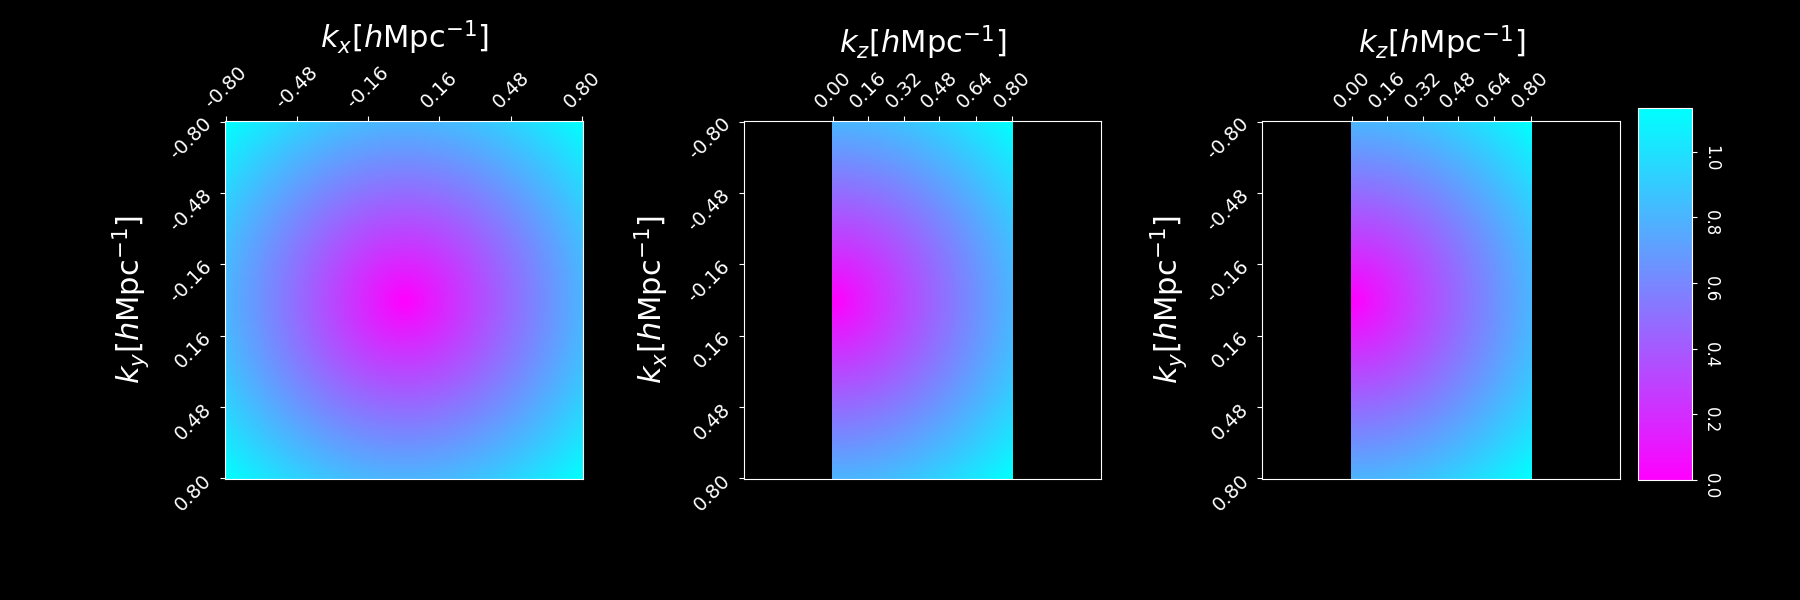

In [34]:
fig, axes = plt.subplots(figsize = (18, 6), nrows = 1, ncols = 3, 
                         sharex = False, sharey = False)
ax1 = axes[0]
ax2 = axes[1]
ax3 = axes[2]

#div_cmap = cm.viridis
div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

print(k_radius[:,0,:].shape)
logscale = False
#fact = 1.
fact = np.sqrt(2)
indcut = 0 if not fshift else len(kx_v)//2 + 1
if logscale:
    im1 = ax1.matshow(k_radius[:,:,0],cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=k.max()*fact))
    im2 = ax2.matshow(k_radius[:,indcut,:],cmap = div_cmap, origin = origin, 
                     norm=colors.LogNorm(vmin=1e-2, vmax=k.max()*fact))
    im3 = ax3.matshow(k_radius[indcut,:,:],cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=k.max()*fact))
else:
    im1 = ax1.matshow(k_radius[:,:,0],cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = k.max()*fact)
    im2 = ax2.matshow(k_radius[:,indcut,:],cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = k.max()*fact)
    im3 = ax3.matshow(k_radius[indcut,:,:],cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = k.max()*fact)

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im3, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kx_v.shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kz_v.shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in ky_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')

ax2.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
#ax2.set(adjustable='box', aspect='equal')
ax2.set_box_aspect(1)

ax3.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_xticks(labelH)
ax3.set_yticks(labelM)
ax3.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax3.xaxis.set_ticks_position('top')
ax3.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax3.xaxis.set_label_position('top')
ax3.yaxis.set_label_position('left')
ax3.set_box_aspect(1)

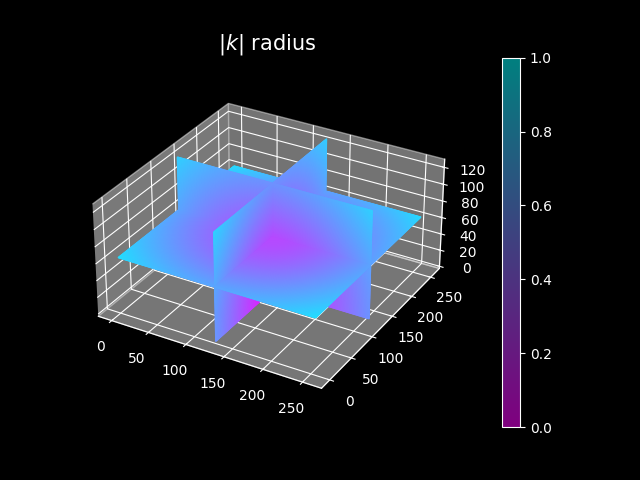

In [22]:
def plot_quadrants(ax, array, fixed_coord, cmap):
    """For a given 3d *array* plot a plane with *fixed_coord*, using four quadrants."""
    nx, ny, nz = array.shape
    index = {
        'x': (nx // 2, slice(None), slice(None)),
        'y': (slice(None), ny // 2, slice(None)),
        'z': (slice(None), slice(None), nz // 2),
    }[fixed_coord]
    plane_data = array[index]

    n0, n1 = plane_data.shape
    quadrants = [
        plane_data[:n0 // 2, :n1 // 2],
        plane_data[:n0 // 2, n1 // 2:],
        plane_data[n0 // 2:, :n1 // 2],
        plane_data[n0 // 2:, n1 // 2:]
    ]

    min_val = array.min()
    max_val = array.max()

    cmap = plt.get_cmap(cmap)

    for i, quadrant in enumerate(quadrants):
        facecolors = cmap((quadrant - min_val) / (max_val - min_val))
        #facecolors = cmap(quadrant)
        if fixed_coord == 'x':
            Y, Z = np.mgrid[0:ny // 2, 0:nz // 2]
            X = nx // 2 * np.ones_like(Y)
            Y_offset = (i // 2) * ny // 2
            Z_offset = (i % 2) * nz // 2
            A = ax.plot_surface(X, Y + Y_offset, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False, alpha = 0.5, cmap = cmap)
        elif fixed_coord == 'y':
            X, Z = np.mgrid[0:nx // 2, 0:nz // 2]
            Y = ny // 2 * np.ones_like(X)
            X_offset = (i // 2) * nx // 2
            Z_offset = (i % 2) * nz // 2
            A = ax.plot_surface(X + X_offset, Y, Z + Z_offset, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False, alpha = 0.5,cmap = cmap)
        elif fixed_coord == 'z':
            X, Y = np.mgrid[0:nx // 2, 0:ny // 2]
            Z = nz // 2 * np.ones_like(X)
            X_offset = (i // 2) * nx // 2
            Y_offset = (i % 2) * ny // 2
            A = ax.plot_surface(X + X_offset, Y + Y_offset, Z, rstride=1, cstride=1,
                            facecolors=facecolors, shade=False, alpha = 0.5, cmap = cmap)
    return A


def figure_3D_array_slices(array,  titlestr,cmap=None):
    """Plot a 3d array using three intersecting centered planes."""
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(array.shape)
    A = plot_quadrants(ax, array, 'x', cmap=cmap)
    plot_quadrants(ax, array, 'y', cmap=cmap)
    plot_quadrants(ax, array, 'z', cmap=cmap)
    plt.title(titlestr, fontsize = 15)
    fig.colorbar(A, pad = 0.1)
    # divider = make_axes_locatable(ax)
    # cad = divider.append_axes("right", size="8%", pad=0.05)
    # mappable = plt.cm.ScalarMappable(cmap=cmap, cax = cad)
    # plt.colorbar(mappable)
    return fig, ax

figure_3D_array_slices(k_radius,r"$|k|$" + " radius", cmap='cool_r')
plt.show()

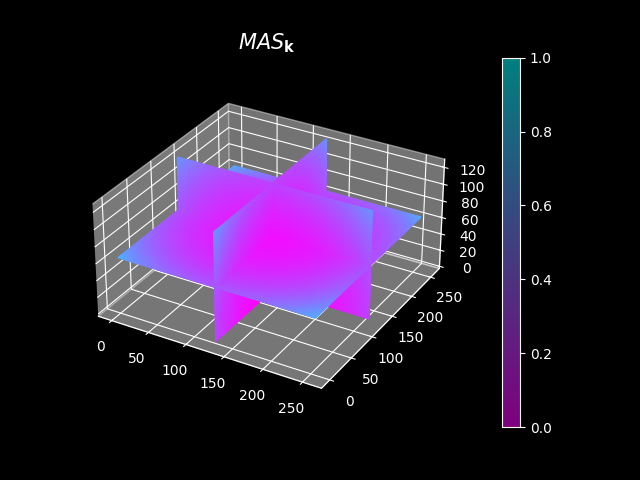

In [23]:
figure_3D_array_slices(MAS_factor,r"$MAS_{\mathbf{k}}$", cmap='cool_r')
plt.show()

In [73]:
delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1))
delta_k = delta_pm_fourier_shift*MAS_factor

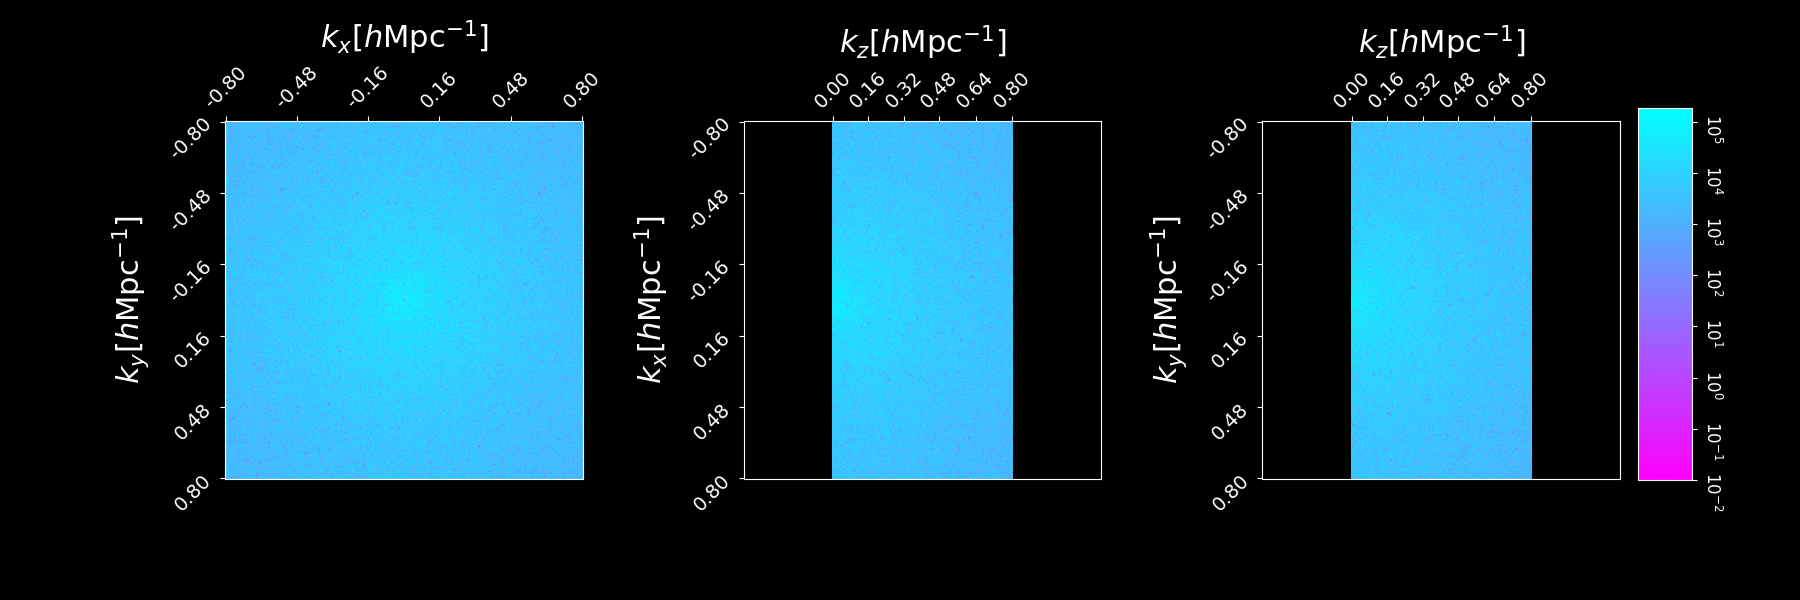

In [74]:
fig, axes = plt.subplots(figsize = (18, 6), nrows = 1, ncols = 3, 
                         sharex = False, sharey = False)
ax1 = axes[0]
ax2 = axes[1]
ax3 = axes[2]

#div_cmap = cm.viridis
div_cmap = cm.cool_r
div_cmap.set_bad('magenta',1.)
origin = "upper"

logscale = True
#fact = 1.
fact = np.sqrt(2)
indcut = 0 if not fshift else len(kx_v)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(delta_k[:,:,0]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(delta_k).max()))
    im2 = ax2.matshow(abs(delta_k[:,indcut,:]),cmap = div_cmap, origin = origin, 
                     norm=colors.LogNorm(vmin=1e-2, vmax=abs(delta_k).max()))
    im3 = ax3.matshow(abs(delta_k[indcut,:,:]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(delta_k).max()))
else:
    im1 = ax1.matshow(abs(delta_k[:,:,0]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = abs(delta_k[:,:,0]).max())
    im2 = ax2.matshow(abs(delta_k[:,indcut,:]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax = abs(delta_k).max())
    im3 = ax3.matshow(abs(delta_k[indcut,:,:]),cmap = div_cmap, origin = origin, 
                      vmin = 0, vmax =abs(delta_k).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im3, cax=myCbar)
cb.ax.minorticks_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kx_v.shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kz_v.shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in ky_v[labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')

ax2.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_ylabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax2.set_xticks(labelH)
ax2.set_yticks(labelM)
ax2.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax2.xaxis.set_ticks_position('top')
ax2.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax2.xaxis.set_label_position('top')
ax2.yaxis.set_label_position('left')
#ax2.set(adjustable='box', aspect='equal')
ax2.set_box_aspect(1)

ax3.set_xlabel(r"$k_z [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax3.set_xticks(labelH)
ax3.set_yticks(labelM)
ax3.set_xticklabels([fmtM(j) for j in kz_v[labelH]], rotation = 45, fontsize = 14)
ax3.xaxis.set_ticks_position('top')
ax3.set_yticklabels([fmtM(j) for j in kx_v[labelM]], rotation = 45, fontsize = 14)
ax3.xaxis.set_label_position('top')
ax3.yaxis.set_label_position('left')
ax3.set_box_aspect(1)

In [75]:
@njit
def fill_fourier_grid(weights_grid, k3D_radius , k_bins, weights1D):
    for ix in numba.prange(k3D_radius.shape[0]):
        for iy in numba.prange(k3D_radius.shape[1]):
            for iz in numba.prange(k3D_radius.shape[2]):
                weights_grid[ix][iy][iz] = np.interp(k3D_radius[ix][iy][iz], k_bins, weights1D) #(x,xp,fp)
    return weights_grid

In [76]:
weights_grid = np.empty(delta_pm_fourier_corr.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, roots[:,1])

In [77]:
print(delta_pm_fourier_corr.nbytes/(1024**2), "Mb")
print(pos_pm.nbytes/(1024**2), "Mb")

64.5 Mb
1536.0 Mb


In [79]:
print("total memory:" ,bytes2human(psutil.virtual_memory()[0]))
print('memory % used:', psutil.virtual_memory()[2])
print("number of cpus :", os.cpu_count())

total memory: 251.5G
memory % used: 22.1
number of cpus : 128


In [80]:
del delta_pm_fourier_np, delta_pm_fourier_shift

In [81]:
print("total memory:" ,bytes2human(psutil.virtual_memory()[0]))
print('memory % used:', psutil.virtual_memory()[2])
print("number of cpus :", os.cpu_count())

total memory: 251.5G
memory % used: 22.1
number of cpus : 128


### Back to displacement (either Anirban or modifications)

In [82]:
try:
    del pos_nb
except:
    pass
phi_k = weights_grid* delta_pm_fourier
print(phi_k.nbytes/(1024**2), "Mb")

129.0 Mb


In [83]:
a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)

IndexError: index 129 is out of bounds for axis 2 with size 129

In [ ]:
# From Pylians
def frequencies(BoxSize,dims):
    kF = 2.0*np.pi/BoxSize;  middle = dims//2;  kN = middle*kF
    kmax_par = middle
    kmax_per = int(np.sqrt(middle**2 + middle**2))
    kmax     = int(np.sqrt(middle**2 + middle**2 + middle**2))
    return kF,kN,kmax_par,kmax_per,kmax

In [ ]:
scale = 2*np.pi*grid/BoxSize # fundamental kF
kxx = np.array(scale*np.fft.fftfreq(grid), dtype='float32')
kyy = np.array(scale*np.fft.fftfreq(grid), dtype='float32')
kzz = np.array(scale*np.fft.rfftfreq(grid), dtype='float32')

grad_x_fourier = -1.0j*kxx[:,np.newaxis, np.newaxis] * potential_filtered
grad_y_fourier = -1.0j*kyy[np.newaxis,:, np.newaxis] * potential_filtered
grad_z_fourier = -1.0j*kzz[np.newaxis, np.newaxis, :] * potential_filtered

# grad_x_real = np.fft.irffn(grad_x_fourier)
# grad_y_real = np.fft.irffn(grad_y_fourier)
# grad_z_real = np.fft.irffn(grad_z_fourier)

In [ ]:
# Initialize
arr_inx  =  pyfftw.empty_aligned((N_CELLS, N_CELLS, N_CELLS//2+1), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((N_CELLS, N_CELLS, N_CELLS//2+1), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((N_CELLS, N_CELLS, N_CELLS//2+1), dtype=prec_out)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier.astype(prec_out)
arr_iny[:] =  grad_y_fourier.astype(prec_out)
arr_inz[:] =  grad_z_fourier.astype(prec_out)

# Instantiate FFTW object
ifftw_objectx = pyfftw.builders.irfftn(arr_inx,  axes=(0,1,2), threads=N_CPU)
ifftw_objecty = pyfftw.builders.irfftn(arr_iny,  axes=(0,1,2), threads=N_CPU)
ifftw_objectz = pyfftw.builders.irfftn(arr_inz,  axes=(0,1,2), threads=N_CPU)

grad_x_real = ifftw_objectx()
grad_y_real = ifftw_objecty()
grad_z_real = ifftw_objectz()

In [ ]:
#Numba marginaly slower than cython, much faster than standard python
@njit
def displace_positions(positions, new_positions, grad_x, grad_y, grad_z, array_length):
    N = positions.shape[0]
    for particle in numba.prange(N):
        
        x_index = np.argmin((positions[N][0] - array_length)**2)
        y_index = np.argmin((positions[N][1] - array_length)**2)
        z_index = np.argmin((positions[N][2] - array_length)**2)
        
        new_positions[N][0] = positions[N][0] + grad_x[x_index][y_index][z_index]
        new_positions[N][1] = positions[N][1] + grad_y[x_index][y_index][z_index]
        new_positions[N][2] = positions[N][2] + grad_z[x_index][y_index][z_index]
        
    return new_positions

In [ ]:
pos_disp = np.empty(pos_pm.shape)

cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)


start = time.time()
pos_disp = displace_positions(pos_pm, pos_disp, grad_x_real, grad_y_real, 
                              grad_z_real, length_grid)

end = time.time()
elapsed = end - start
print("%.2f seconds of computation"%elapsed)

In [26]:
a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
#pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize, threshold=1000./128)

IndexError: index 129 is out of bounds for axis 2 with size 129

In [57]:
pos_corrected = correct_pos(pos_pm, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize, threshold=BoxSize/grid)

NameError: name 'a_x' is not defined

In [ ]:
delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

In [23]:
#rfftfreq will go from 0 to 0.5 = f/f_{nyquist}
k_test = 2*np.pi/BoxSize*grid *np.fft.rfftfreq(n=grid, d = 1)
#k_test = np.fft.rfftfreq(n=grid, d = 1)
print(k_test[-1])

0.8042477193189871


In [ ]:
# MAS kernel corection
def MAS_corr(x, powc):
    out = np.ones(x.shape)
    out[np.where(x!=0.)]= np.power(x[np.where(x!=0.)]/np.sin(x[np.where(x!=0.)]), powc)
    return out

def fourier_shells_ksquare(res, box_size, corr_cic = False):

    scale = 2*np.pi*res/box_size # fundamental kF
    k_x = np.array(scale*np.fft.fftfreq(res), dtype='float32')
    k_y = np.array(scale*np.fft.fftfreq(res), dtype='float32')
    k_z = np.array(scale*np.fft.rfftfreq(res), dtype='float32')

    if corr_cic:
        
        m_x, m_y, m_z = MAS_corr(k_x,2), MAS_corr(k_y,2), MAS_corr(k_z,2)

        k_x *= m_x
        k_y *= m_y
        k_z *= m_z
        
         #Transforming the axes to 3D grids
        kx, ky, kz = np.meshgrid(k_x, k_y, k_z)
    else:
        #Transforming the axes to 3D grids
        kx, ky, kz = np.meshgrid(k_x, k_y, k_z)

    k_square_grid = np.sqrt(kx**2 + ky**2 + kz**2)
        
    #return k_square_grid[:,:,:res//2+1] # real-valued field -> redundent from res//2+1 in Fourier last axis
    return k_square_grid

In [ ]:
Q_fourier_grid = np.empty(Green_function.shape)
#Numba marginaly slower than cython
@njit
def fill_Q_fourier_grid(Qgrid, k3D , k_bins, Qk):
    for ix in numba.prange(k3D.shape[0]):
        for iy in numba.prange(k3D.shape[1]):
            for iz in numba.prange(k3D.shape[2]):
                Qgrid[ix][iy][iz] = np.interp(np.sqrt(k3D[ix][iy][iz]), k_bins, Qk)
    return Qgrid

## 2-2) Partial correlation case
\begin{equation}
    \phi (k) = \frac{\gamma_k}{k^2} F_k
\end{equation}
where
\begin{equation}
    \langle F_k \Delta_{k^\prime}^\ast \rangle = r(k) \sqrt{P_\Delta(k) \times P_{F} (k)} \delta^{\rm D} (\vec{k} - \vec{k}^\prime)
\end{equation}
Choose e.g. $F$ to be the mass-weighted density field

**This is only relevant in the halo case.** :)

## 2-3) Uncorrelated case
\begin{equation}
    Q(k) = \frac{\beta_k^2}{k^4} P(k),
\end{equation}
where $\beta \geq 0$.